# Notebook 1 - eda.ipynb

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 6)

E1: Load and Inspect

In [2]:
df = pd.read_csv('../data/citibike_weather_daily.csv')
print(df.shape)
df.head()

(1610, 10)


,ride_date,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,day_of_week,month
0,2013-07-01,16650,16.309988,74.8,78.1,73.4,7.8,0.00,Monday,7
1,2013-07-02,22745,15.968826,76.1,82.9,73.0,8.0,0.73,Tuesday,7
2,2013-07-03,21864,16.238808,78.5,84.9,73.9,8.8,0.06,Wednesday,7
3,2013-07-04,22326,21.218474,82.0,91.0,73.9,8.6,0.96,Thursday,7
4,2013-07-05,21842,18.040443,84.4,93.0,75.9,9.0,0.00,Friday,7


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ride_date         1610 non-null   str    
 1   num_rides         1610 non-null   int64  
 2   avg_duration_min  1610 non-null   float64
 3   temp_f            1610 non-null   float64
 4   max_temp_f        1610 non-null   float64
 5   min_temp_f        1610 non-null   float64
 6   wind_speed_knots  1610 non-null   float64
 7   precip_in         1610 non-null   float64
 8   day_of_week       1610 non-null   str    
 9   month             1610 non-null   int64  
dtypes: float64(6), int64(2), str(2)
memory usage: 125.9 KB


In [6]:
df.dtypes

ride_date               str
num_rides             int64
avg_duration_min    float64
temp_f              float64
max_temp_f          float64
min_temp_f          float64
wind_speed_knots    float64
precip_in           float64
day_of_week             str
month                 int64
dtype: object

E2: Profile the Distributions

In [8]:
df.describe()

,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,month
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,32986.783230,15.425627,57.368509,67.317081,49.295901,9.013913,0.178398,6.544099
std,16910.147968,3.652633,17.876211,18.349408,17.832318,3.241211,2.508762,3.323772
min,876.000000,9.495396,8.300000,18.000000,1.000000,2.300000,0.000000,1.000000
25%,20505.500000,13.112342,43.625000,53.700000,35.700000,6.700000,0.000000,4.000000
50%,32272.500000,14.860057,59.300000,70.000000,51.100000,8.500000,0.000000,7.000000
75%,42915.750000,17.121551,73.500000,82.900000,64.900000,10.800000,0.060000,9.000000
max,78458.000000,81.110084,92.500000,100.900000,82.900000,22.400000,99.990000,12.000000


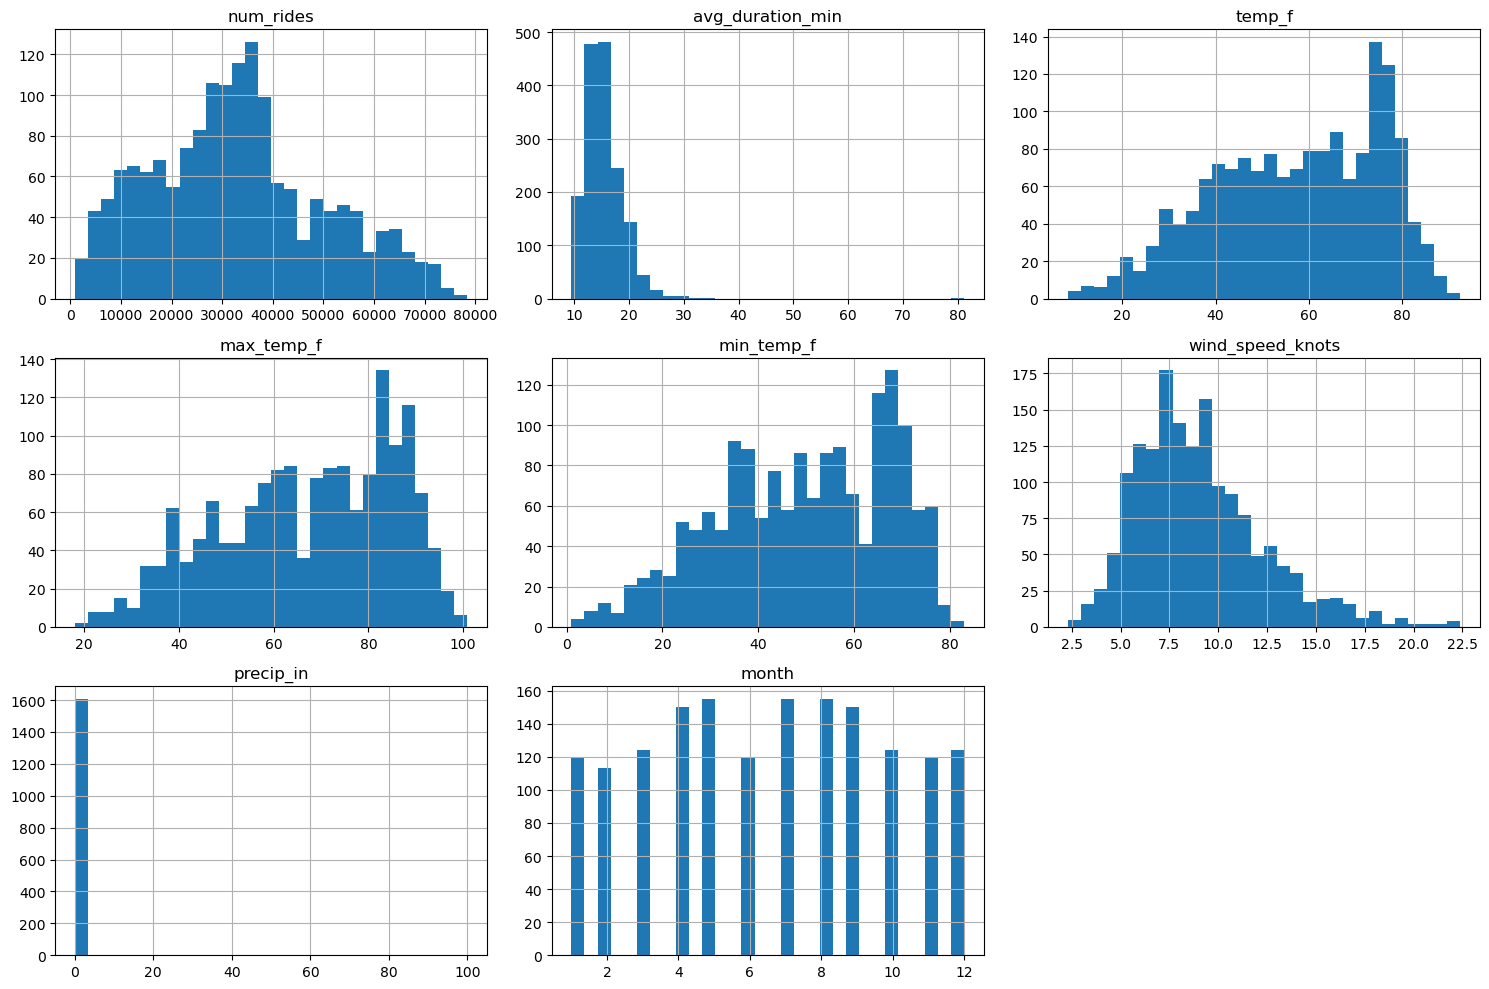

In [15]:
numerical_cols = ['num_rides', 'avg_duration_min', 'temp_f', 'max_temp_f', 'min_temp_f', 'wind_speed_knots', 'precip_in', 'month']

df[numerical_cols].hist(bins=30, figsize=(15, 10),)
plt.tight_layout()
plt.show()

E3: Relationships With the Target

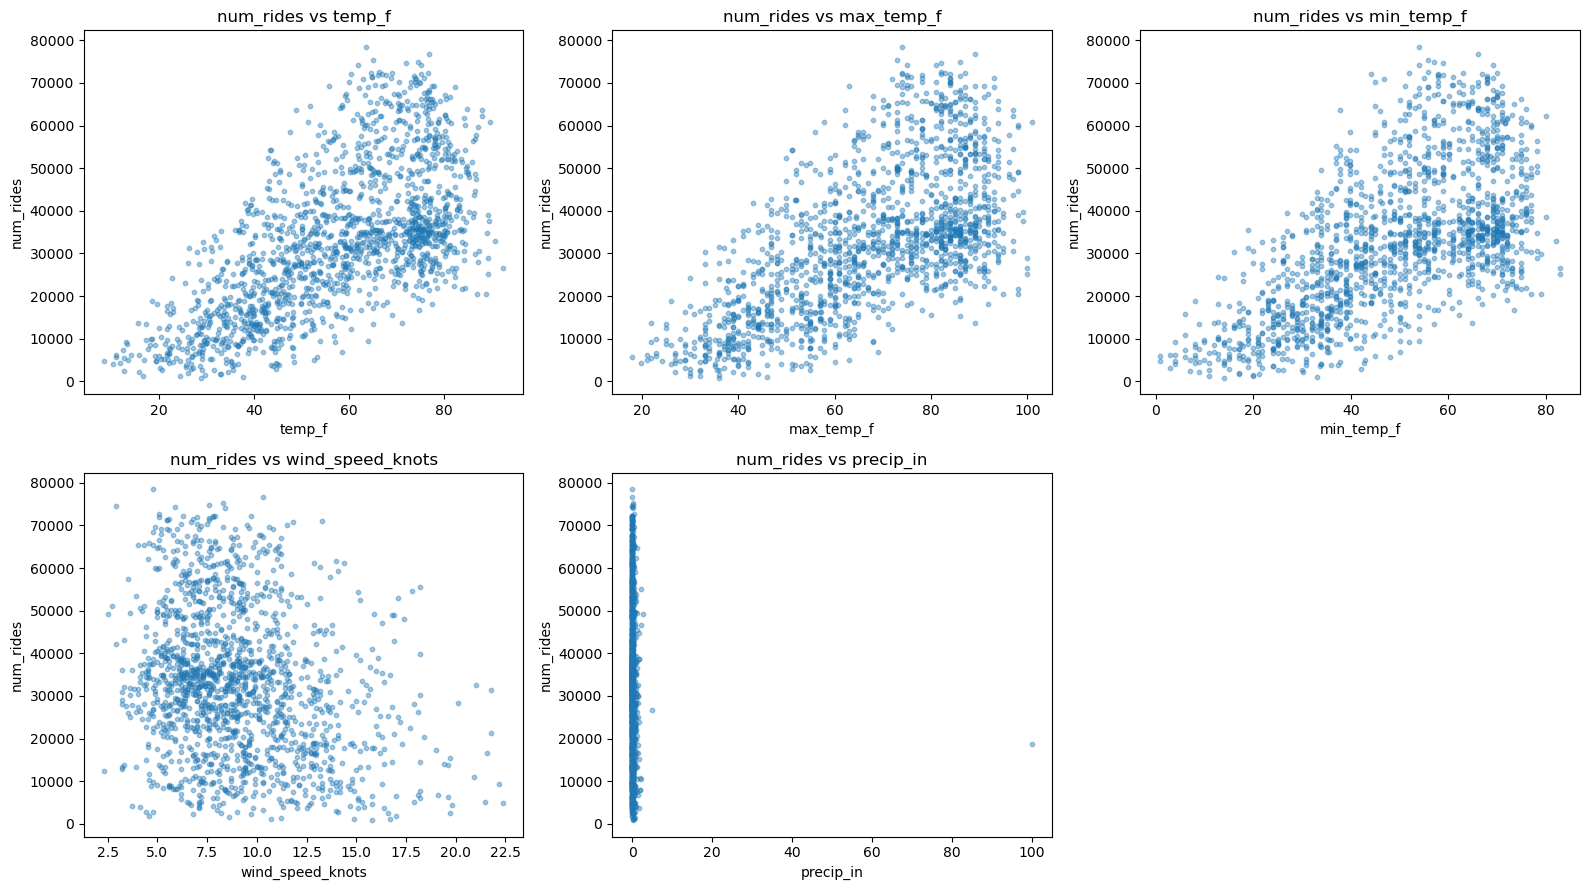

In [18]:
weather_cols = ['temp_f', 'max_temp_f', 'min_temp_f', 'wind_speed_knots', 'precip_in']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for col, ax in zip(weather_cols, axes.flat):
    df.plot.scatter(x=col, y='num_rides', alpha=0.4, s=10, ax=ax, title=f'num_rides vs {col}')

axes.flat[-1].axis('off')

plt.tight_layout()
plt.show()

In [20]:
print(df[weather_cols + ['num_rides']].corr()['num_rides'])

print()
print("Correlation btwn the temperature columns:")
print(df[['temp_f', 'max_temp_f', 'min_temp_f']].corr())


temp_f              0.642993
max_temp_f          0.643271
min_temp_f          0.622907
wind_speed_knots   -0.256536
precip_in          -0.032901
num_rides           1.000000
Name: num_rides, dtype: float64

Correlation btwn the temperature columns:
              temp_f  max_temp_f  min_temp_f
temp_f      1.000000    0.976912    0.978236
max_temp_f  0.976912    1.000000    0.952614
min_temp_f  0.978236    0.952614    1.000000


E4: Ridership Over Time

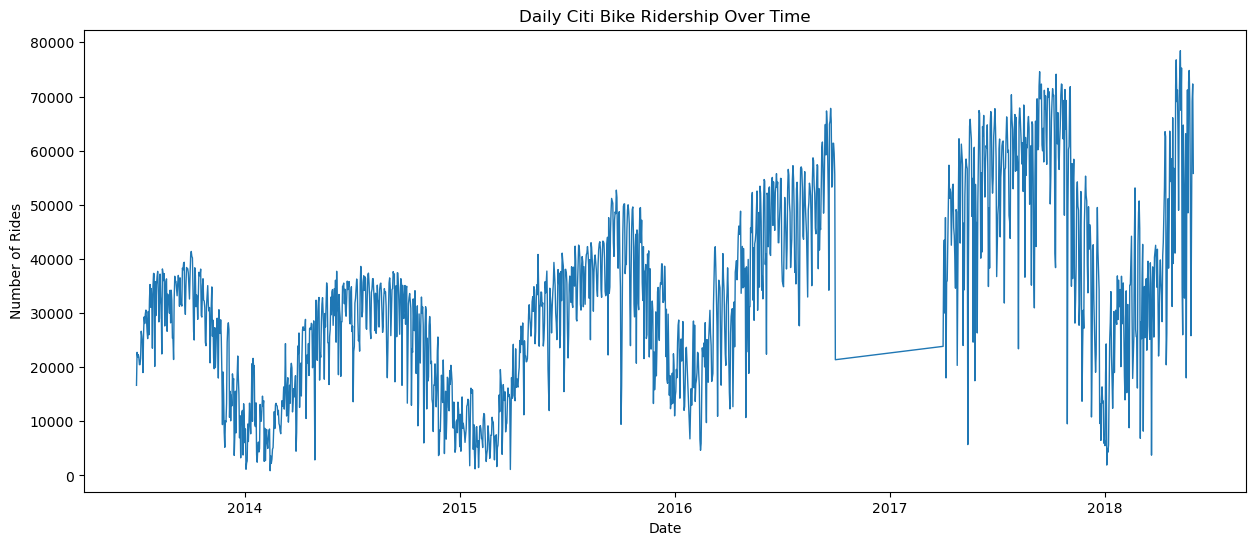

In [21]:
df_time = df.copy()
df_time['ride_date_parsed'] = pd.to_datetime(df_time['ride_date'])

plt.figure(figsize=(15, 6))
plt.plot(df_time['ride_date_parsed'], df_time['num_rides'], linewidth=1)
plt.title('Daily Citi Bike Ridership Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Rides')
plt.show()

July Average Ridership by Year:
year
2013    27206.967742
2014    31252.967742
2015    35021.806452
2016    44519.677419
2017    55987.064516
Name: num_rides, dtype: float64


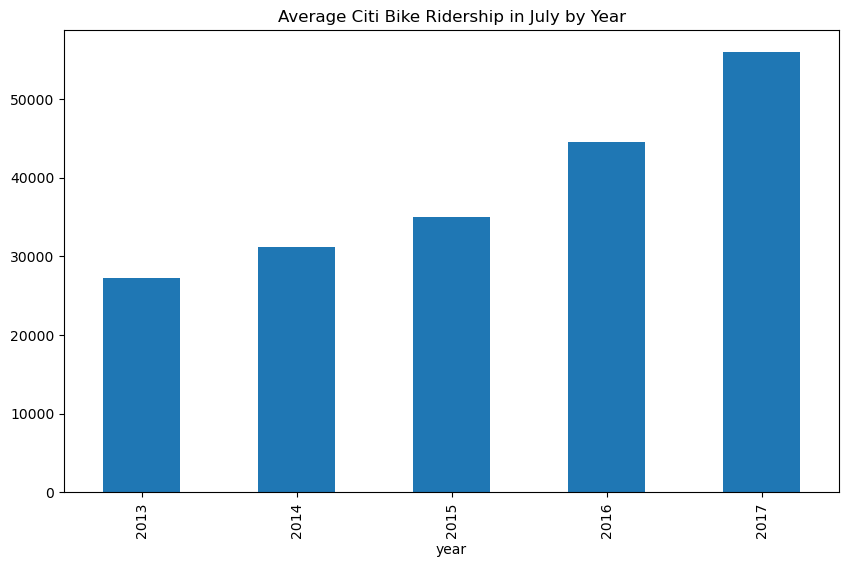

In [23]:
df_time['year'] = df_time['ride_date_parsed'].dt.year
df_time['month'] = df_time['ride_date_parsed'].dt.month

july = df_time[df_time['month'] == 7]
july_by_year = july.groupby('year')['num_rides'].mean()

print('July Average Ridership by Year:')
print(july_by_year)

july_by_year.plot(kind='bar', figsize=(10, 6))
plt.title('Average Citi Bike Ridership in July by Year')
plt.show()

E5: The Weekly Rhythm

weekly_average:
day_of_week
Monday       33296.830435
Tuesday      35485.243478
Wednesday    36264.731602
Thursday     35737.753247
Friday       34229.373913
Saturday     28562.554585
Sunday       27260.650655
Name: num_rides, dtype: float64


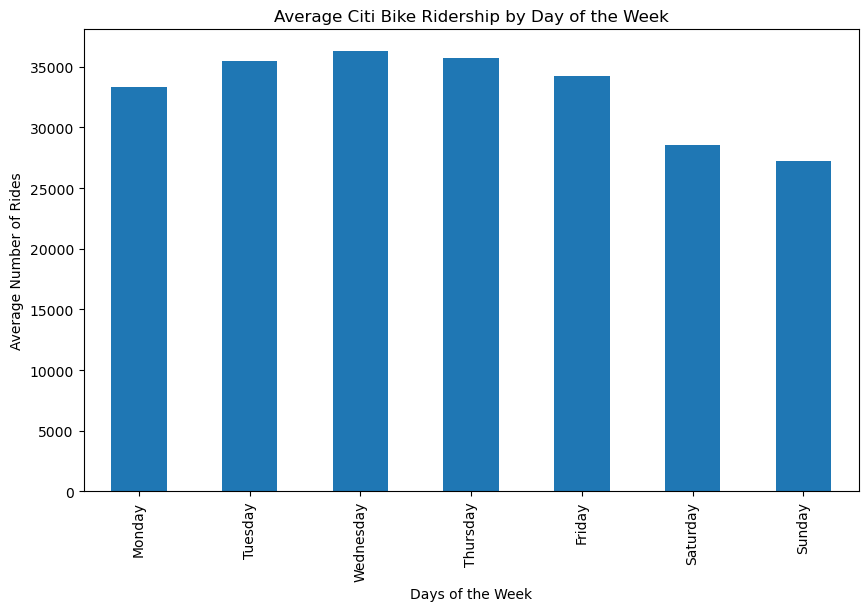

In [26]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekly_average = df_time.groupby('day_of_week')['num_rides'].mean().reindex(day_order)
print('weekly_average:')
print(weekly_average)

weekly_average.plot(kind='bar', figsize=(10, 6))
plt.title('Average Citi Bike Ridership by Day of the Week')
plt.ylabel('Average Number of Rides')
plt.xlabel('Days of the Week')
plt.show()

E6: The Missing Days

In [ ]:
df_dates = pd.to_datetime(df['ride_date'])

full_range = pd.date_range(start=df_dates.min(), end=df_dates.max(), freq='D')
missing_dates = full_range.difference(df_dates)

print(f"Full Date Range: {df_dates.min().date()} to {df_dates.max().date()}")
print(f"Missing Dates: {len(missing_dates)}")
print(f"Total Days in Range: {len(full_range)}")
print(f"Days actually in DataFrame: {len(df_dates)}")



Full Date Range: 2013-07-01 to 2018-05-31
Missing Dates: 186
Total Days in Range: 1796
Days actually in DataFrame: 1610
2016-01-23 to 2016-01-26  (4 days)
2016-10-01 to 2017-03-31  (182 days)


In [31]:
missing_series = pd.Series(sorted(missing_dates))
groups = (missing_series - pd.to_timedelta(range(len(missing_series)), unit='D'))

for _, g in missing_series.groupby(groups):
    print(f"{g.iloc[0].date()} to {g.iloc[-1].date()}  ({len(g)} days)")

2016-01-23 to 2016-01-26  (4 days)
2016-10-01 to 2017-03-31  (182 days)
